In [7]:
def newtonsmethod(func, funcderiv,x,n):
    def f(x):
        f = eval(func)
        return f
    
    def df(x):
        df = eval(funcderiv)
        return df
    for itercept in range(1,n):
        i = x - (f(x)/df(x))
        x = i
    print(f"A raiz foi encontrada em {x} depois de {n} interações") 

newtonsmethod("x**2 - 2", "2*x", 2, 7)

A raiz foi encontrada em 1.414213562373095 depois de 7 interações


In [11]:
import sympy as sp

def newtonsmethod():
    # Solicitar a função, precisão e número máximo de iterações ao usuário
    func_input = input("Digite a função (em termos de x): ")
    precision = int(input("Digite o número de casas decimais desejadas para a precisão: "))
    max_iterations = int(input("Digite o número máximo de iterações: "))
    x0 = float(input("Digite o valor inicial de x: "))

    # Definindo a variável simbólica
    x = sp.symbols('x')
    
    try:
        func = sp.sympify(func_input)  # Converte a string da função em uma expressão simbólica
    except sp.SympifyError:
        print("Entrada inválida. Certifique-se de usar 'sin', 'cos', e operadores válidos.")
        return
    
    func_deriv = sp.diff(func, x)

    # Funções para avaliação
    f = sp.lambdify(x, func)
    df = sp.lambdify(x, func_deriv)

    print("\nIniciando o Método de Newton...")
    print(f"Função: {func_input}")
    print(f"Derivada: {func_deriv}\n")

    # Iterações do método de Newton
    for i in range(max_iterations):
        f_x0 = f(x0)
        df_x0 = df(x0)
        
        # Exibir informações detalhadas da iteração
        print(f"Iteração {i+1}:")
        print(f"  x0 = {round(x0, precision)}")
        print(f"  f(x0) = {round(f_x0, precision)}")
        print(f"  f'(x0) = {round(df_x0, precision)}")
        
        if df_x0 == 0:
            print("A derivada é zero. O método não pode continuar.")
            return
        
        x_new = x0 - (f_x0 / df_x0)
        
        print(f"  x_new = {round(x_new, precision)}\n")
        
        # Verificar a condição de parada (precisão)
        if round(x_new, precision) == round(x0, precision):
            print(f"A raiz foi encontrada em {round(x_new, precision)} após {i+1} interações.")
            return
        
        x0 = x_new

    print(f"A raiz aproximada após {max_iterations} interações é {round(x0, precision)}.")

# Chamar a função
newtonsmethod()


Iniciando o Método de Newton...
Função: cos(x) + x**2
Derivada: 2*x - sin(x)

Iteração 1:
  x0 = 5.0
  f(x0) = 25.28366
  f'(x0) = 10.95892
  x_new = 2.69287

Iteração 2:
  x0 = 2.69287
  f(x0) = 6.35055
  f'(x0) = 4.95193
  x_new = 1.41043

Iteração 3:
  x0 = 1.41043
  f(x0) = 2.14899
  f'(x0) = 1.83369
  x_new = 0.23848

Iteração 4:
  x0 = 0.23848
  f(x0) = 1.02857
  f'(x0) = 0.24074
  x_new = -4.03415

Iteração 5:
  x0 = -4.03415
  f(x0) = 15.64691
  f'(x0) = -8.84697
  x_new = -2.26553

A raiz aproximada após 5 interações é -2.26553.


In [9]:
import sympy as sp
import numpy as np

#utilizar 0 0.001 e 5 como entrada dos valores. A função é pré definida

def funcao(x):
    return 4 * np.cos(x) - np.exp(x)

def derivada(x):
    return -4 * np.sin(x) - np.exp(x)

def newton_raphson():
    # Solicitar a entrada do usuário
    try:
        x0 = float(input("Digite a aproximação inicial: "))
        erro = float(input("Digite o valor admitido para o erro: "))
        max_iteracoes = int(input("Digite o número máximo de iterações: "))
    except ValueError:
        print("Entrada inválida. Por favor, insira números válidos.")
        return

    erro_iterado = float('inf')  # Inicializa o erro iterado com infinito
    n = 1  # Contador de iterações

    # Abrir arquivo para registrar os resultados
    with open("Saida_Newton.txt", "a") as saida:
        saida.write("\tZeros de Funções - Método de Newton-Raphson\n\n")
        
        print("\n\tMétodo de Newton-Raphson")
        
        # Iterações do método
        while erro_iterado >= erro and n <= max_iteracoes:
            xn = x0 - (funcao(x0) / derivada(x0))  # Aplicação da fórmula
            erro_iterado = abs(funcao(xn))  # Erro absoluto

            # Exibir informações da iteração
            print(f"\n\n\tIteração: {n}")
            print(f"\tValores: x({n})= {xn:.20f}; erro= {erro_iterado:.20f}")

            # Escrever no arquivo
            saida.write(f"\n\n\tIteração: {n}\n")
            saida.write(f"\tValores: x({n})= {xn:.20f}; erro= {erro_iterado:.20f}\n")

            x0 = xn  # Atualiza x0 para a próxima iteração
            n += 1  # Incrementa contador

        if erro_iterado < erro:
            print(f"\n\n\tA raiz procurada vale: {xn:.20f}")
            saida.write(f"\n\n\tA raiz procurada vale: {xn:.20f}\n")
        else:
            print("\n\n\tNúmero máximo de iterações alcançado sem convergência.")
    
if __name__ == "__main__":
    newton_raphson()

Entrada inválida. Por favor, insira números válidos.



Iniciando o Método de Newton...
Função: x**2 + cos(x)
Derivada: 2*x - sin(x)

Iteração 1:
  x0 = 5.0
  f(x0) = 25.28366
  f'(x0) = 10.95892
  x_new = 2.69287

Iteração 2:
  x0 = 2.69287
  f(x0) = 6.35055
  f'(x0) = 4.95193
  x_new = 1.41043

Iteração 3:
  x0 = 1.41043
  f(x0) = 2.14899
  f'(x0) = 1.83369
  x_new = 0.23848

Iteração 4:
  x0 = 0.23848
  f(x0) = 1.02857
  f'(x0) = 0.24074
  x_new = -4.03415

Iteração 5:
  x0 = -4.03415
  f(x0) = 15.64691
  f'(x0) = -8.84697
  x_new = -2.26553

A raiz aproximada após 5 interações é -2.26553.


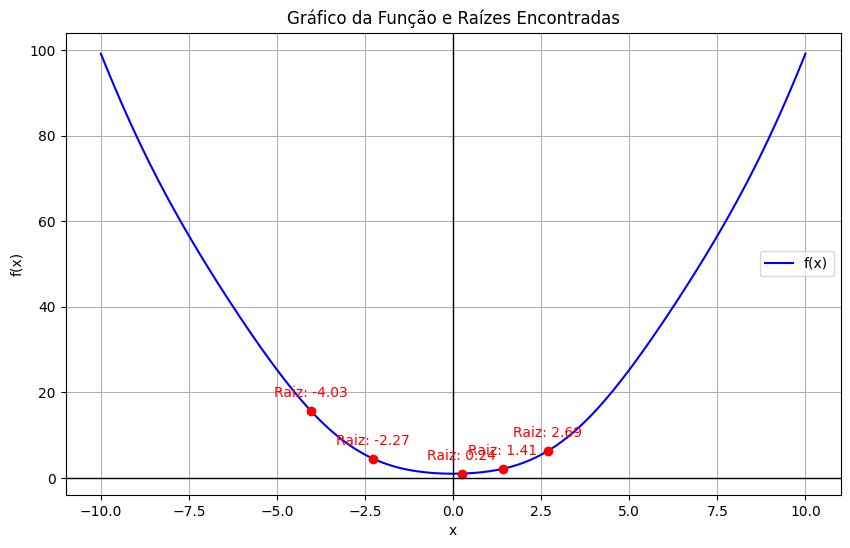

In [12]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def newton_raphson():
    # Solicitar a função, precisão e número máximo de iterações ao usuário
    func_input = input("Digite a função (em termos de x, use 'sin' e 'cos'): ")
    precision = int(input("Digite o número de casas decimais desejadas para a precisão: "))
    max_iterations = int(input("Digite o número máximo de iterações: "))
    x0 = float(input("Digite o valor inicial de x: "))
    
    # Definindo a variável simbólica
    x = sp.symbols('x')
    
    # Criar a função usando sympy
    try:
        func = sp.sympify(func_input)  # Converte a string da função em uma expressão simbólica
    except sp.SympifyError:
        print("Entrada inválida. Certifique-se de usar 'sin', 'cos', e operadores válidos.")
        return
    
    # Calcular a derivada da função
    func_deriv = sp.diff(func, x)  # Calcula a derivada da função

    # Funções para avaliação
    f = sp.lambdify(x, func)  # Cria uma função que pode ser chamada com valores numéricos
    df = sp.lambdify(x, func_deriv)  # Cria uma função para a derivada

    print("\nIniciando o Método de Newton...")
    print(f"Função: {func}")
    print(f"Derivada: {func_deriv}\n")

    # Listas para armazenar as iterações e raízes encontradas
    roots = []
    
    # Iterações do método de Newton
    for i in range(max_iterations):
        f_x0 = f(x0)
        df_x0 = df(x0)
        
        if df_x0 == 0:
            print("A derivada é zero. O método não pode continuar.")
            return
        
        x_new = x0 - (f_x0 / df_x0)
        
        # Exibir informações detalhadas da iteração
        print(f"Iteração {i+1}:")
        print(f"  x0 = {round(x0, precision)}")
        print(f"  f(x0) = {round(f_x0, precision)}")
        print(f"  f'(x0) = {round(df_x0, precision)}")
        print(f"  x_new = {round(x_new, precision)}\n")
        
        roots.append(x_new)  # Armazena a raiz encontrada
        
        # Verificar a condição de parada (precisão)
        if round(x_new, precision) == round(x0, precision):
            print(f"A raiz foi encontrada em {round(x_new, precision)} após {i+1} interações.")
            break
        
        x0 = x_new

    else:
        print(f"A raiz aproximada após {max_iterations} interações é {round(x0, precision)}.")

    # Visualização do gráfico
    plot_function_and_roots(func, roots)

def plot_function_and_roots(func, roots):
    # Gerar valores para o gráfico
    x_vals = np.linspace(-10, 10, 400)
    y_vals = [func.evalf(subs={sp.symbols('x'): val}) for val in x_vals]

    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label='f(x)', color='blue')
    
    # Marcar as raízes encontradas
    for root in roots:
        plt.plot(root, func.evalf(subs={sp.symbols('x'): root}), 'ro')  # Raiz em vermelho
        plt.annotate(f'Raiz: {root:.2f}', xy=(root, func.evalf(subs={sp.symbols('x'): root})), 
                     textcoords="offset points", xytext=(0,10), ha='center', color='red')

    plt.axhline(0, color='black', lw=1)  # Linha horizontal em y=0
    plt.axvline(0, color='black', lw=1)  # Linha vertical em x=0
    
    plt.title('Gráfico da Função e Raízes Encontradas')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid()
    plt.legend()
    
    plt.show()

# Chamar a função principal
newton_raphson()